# Week 1 — Activation Extraction

**RQ1: Temporal Horizon Detection — Experimental Setup**

Extracts last-token residual stream activations at every layer from `meta-llama/Meta-Llama-3.1-8B`
for all 300 prompts in the verified implicit dataset (no surface temporal cues).

Outputs `activations_immediate.pt` and `activations_long_term.pt` of shape `[300, n_layers, d_model]`
— raw material for Week 2 linear probe training and CAA steering vectors.

In [39]:
%%bash
git clone https://github.com/Avi161/temporal-awareness.git
cd temporal-awareness
git checkout research/rq1-week1-extraction
pip install -e '.[dev]' -q

Your branch is up to date with 'origin/research/rq1-week1-extraction'.


fatal: destination path 'temporal-awareness' already exists and is not an empty directory.
Already on 'research/rq1-week1-extraction'


In [40]:
import os
import sys

os.chdir('/content/temporal-awareness')
sys.path.insert(0, '/content/temporal-awareness')

import json
from pathlib import Path

import torch
from tqdm import tqdm

from src.inference import ModelRunner
from src.inference.backends import ModelBackend
from src.intertemporal.common.project_paths import get_experiment_dir
from scripts.week1.activation_extractor import (
    load_implicit_dataset,
    build_prompts,
    extract_activations_for_prompts,
    save_extraction_results,
)

In [41]:
# Primary model — 16 GB VRAM recommended
# Note: TransformerLens uses "Llama-3.1-8B" (no "Meta-" prefix)
MODEL_NAME = "meta-llama/Llama-3.1-8B"
# MODEL_NAME = "mistralai/Mistral-7B-v0.1"  # fallback if VRAM constrained

DATASET_PATH = Path("data/raw/temporal_scope/temporal_scope_explicit_expanded_500.json")
OUT_DIR = get_experiment_dir() / "week1_activation_extraction"
OUT_DIR.mkdir(parents=True, exist_ok=True)

In [42]:
pairs, metadata = load_implicit_dataset(DATASET_PATH)
print("Dataset metadata:")
print(json.dumps(metadata, indent=2))
print(f"\nLoaded {len(pairs)} pairs")
print("\nFirst 3 pairs:")
for p in pairs[:3]:
    print(p)

Dataset metadata:
{
  "dimension": "temporal_scope",
  "style": "explicit_markers",
  "description": "500 high-quality explicit temporal scope pairs WITH temporal words. Designed for training temporal horizon detection.",
  "n_pairs": 500,
  "validation": "Pre-validated for temporal keyword presence, structural balance, and clear temporal distinction",
  "created": "2025-02-01",
  "version": "1.0",
  "categories": [
    "planning",
    "decision_making",
    "problem_solving",
    "investment",
    "priorities",
    "thinking",
    "tradeoffs",
    "goals",
    "action",
    "vision",
    "risk_management",
    "resource_allocation",
    "strategy_formation",
    "change_management",
    "innovation",
    "leadership",
    "communication",
    "evaluation",
    "learning",
    "adaptation",
    "hiring",
    "product_development",
    "customer_relations",
    "financial_planning",
    "team_building"
  ]
}

Loaded 500 pairs

First 3 pairs:
{'id': 1, 'category': 'planning', 'question':

In [43]:
immediate_prompts, long_term_prompts, categories = build_prompts(pairs)
print("--- Immediate prompt [0] ---")
print(immediate_prompts[0])
print("\n--- Long-term prompt [0] ---")
print(long_term_prompts[0])
print(f"\nCategories (first 5): {categories[:5]}")

--- Immediate prompt [0] ---
When developing a roadmap for this initiative, consider:

Choices:
(A) What we can deliver in the next 30 days

--- Long-term prompt [0] ---
When developing a roadmap for this initiative, consider:

Choices:
(B) What position we want in 10 years

Categories (first 5): ['planning', 'planning', 'planning', 'planning', 'planning']


In [ ]:
import os
from pathlib import Path
from dotenv import load_dotenv
from huggingface_hub import login

# Search for .env in cwd and one level up (covers both repo root and notebooks/ launch)
_env = next((p for p in [Path.cwd() / ".env", Path.cwd().parent / ".env"] if p.exists()), None)
if _env:
    load_dotenv(_env)

hf_token = os.environ.get("HF_TOKEN")
if not hf_token:
    raise ValueError("HF_TOKEN not found — add it to .env at the repo root")

login(token=hf_token)

In [45]:
runner = ModelRunner(
    MODEL_NAME,
    backend=ModelBackend.TRANSFORMERLENS,
    dtype=torch.float16,
)
print(f"n_layers = {runner.n_layers}")
print(f"d_model  = {runner.d_model}")

Loading meta-llama/Llama-3.1-8B on cuda (TransformerLens)...


Loading checkpoint shards:   0%|          | 0/4 [00:00<?, ?it/s]

Loaded pretrained model meta-llama/Llama-3.1-8B into HookedTransformer
Model loaded: ModelBackend.TRANSFORMERLENS meta-llama/Llama-3.1-8B (chat=False)
  n_layers=32, d_model=4096

n_layers = 32
d_model  = 4096


In [46]:
all_names = runner.get_all_names_for_internals()
resid_names = [n for n in all_names if "hook_resid_post" in n]
print(f"Found {len(resid_names)} hook_resid_post layers")
print("First 3:", resid_names[:3])
print("Last 3: ", resid_names[-3:])

Found 32 hook_resid_post layers
First 3: ['blocks.0.hook_resid_post', 'blocks.1.hook_resid_post', 'blocks.2.hook_resid_post']
Last 3:  ['blocks.29.hook_resid_post', 'blocks.30.hook_resid_post', 'blocks.31.hook_resid_post']


In [47]:
test_prompt = immediate_prompts[0]
logits, cache = runner.run_with_cache(
    test_prompt,
    names_filter=lambda n: "hook_resid_post" in n,
)
sample_act = cache["blocks.0.hook_resid_post"][0, -1, :]
print(f"Logits shape:           {logits.shape}")
print(f"Sample activation shape: {sample_act.shape}  (d_model={runner.d_model})")
assert sample_act.shape[0] == runner.d_model, "d_model mismatch"
assert torch.isfinite(sample_act).all(), "Non-finite values in sample activation"
print("Sanity check passed.")

Logits shape:           torch.Size([1, 24, 128256])
Sample activation shape: torch.Size([4096])  (d_model=4096)
Sanity check passed.


In [48]:
acts_immediate = extract_activations_for_prompts(runner, immediate_prompts, desc="Immediate")
print(f"Shape: {acts_immediate.shape}")  # expected [300, n_layers, d_model]

Immediate: 100%|██████████| 500/500 [00:43<00:00, 11.38it/s]


Shape: torch.Size([500, 32, 4096])


In [49]:
acts_long_term = extract_activations_for_prompts(runner, long_term_prompts, desc="Long-term")
print(f"Shape: {acts_long_term.shape}")  # expected [300, n_layers, d_model]

Long-term: 100%|██████████| 500/500 [00:44<00:00, 11.33it/s]


Shape: torch.Size([500, 32, 4096])


In [50]:
save_extraction_results(
    OUT_DIR,
    acts_immediate,
    acts_long_term,
    categories,
    pairs,
    MODEL_NAME,
    DATASET_PATH,
)
print(f"Saved to: {OUT_DIR}")
for f in sorted(OUT_DIR.iterdir()):
    size_mb = f.stat().st_size / 1e6
    print(f"  {f.name:40s}  {size_mb:.1f} MB")

Saved to: /content/temporal-awareness/out/experiments/week1_activation_extraction
  activations_immediate.pt                  131.1 MB
  activations_long_term.pt                  131.1 MB
  metadata.json                             0.0 MB
  pair_metadata.json                        0.0 MB


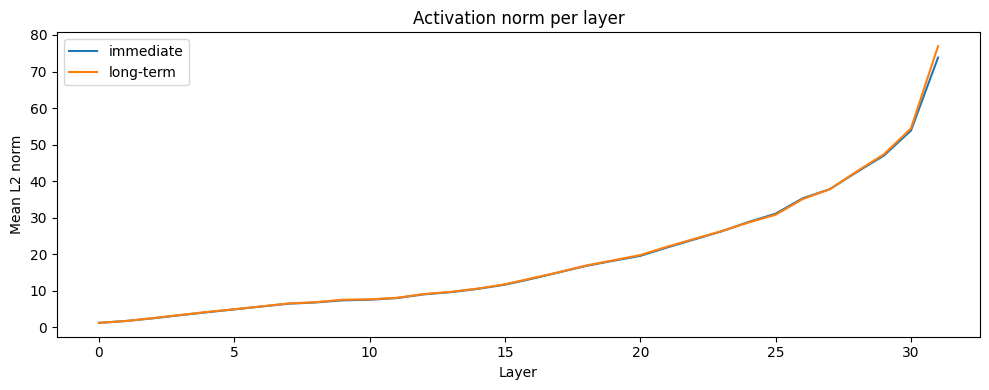

All values finite: OK


In [51]:
import matplotlib.pyplot as plt

# Verification: per-layer L2 norm distribution — should be smooth
norms_imm = acts_immediate.norm(dim=-1).mean(dim=0).cpu()  # [n_layers]
norms_lt  = acts_long_term.norm(dim=-1).mean(dim=0).cpu()

plt.figure(figsize=(10, 4))
plt.plot(norms_imm, label="immediate")
plt.plot(norms_lt,  label="long-term")
plt.xlabel("Layer")
plt.ylabel("Mean L2 norm")
plt.legend()
plt.title("Activation norm per layer")
plt.tight_layout()
plt.show()

# Verify finite values
assert torch.isfinite(acts_immediate).all(), "Non-finite values in acts_immediate"
assert torch.isfinite(acts_long_term).all(), "Non-finite values in acts_long_term"
print("All values finite: OK")

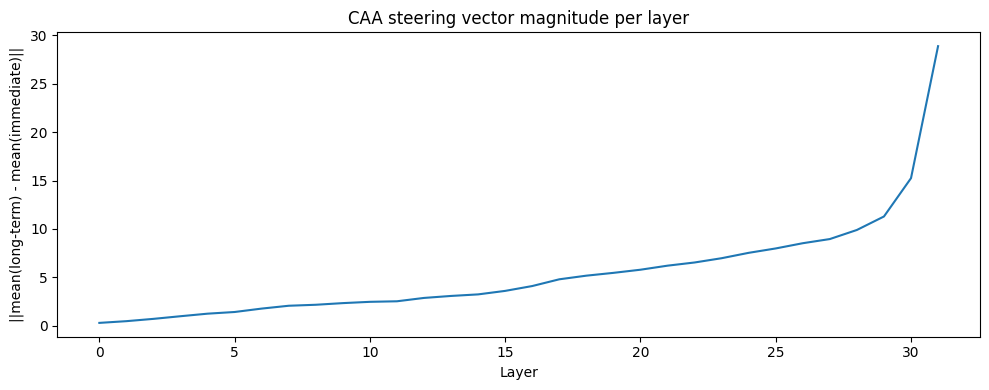

Peak CAA magnitude at layer 31 (of 32)


In [52]:
# Steering vector preview: mean activation difference per layer
# Norm should peak in middle-to-late layers (consistent with interpretability literature)
diff = (acts_long_term - acts_immediate).mean(dim=0)  # [n_layers, d_model]
diff_norms = diff.norm(dim=-1).cpu()

plt.figure(figsize=(10, 4))
plt.plot(diff_norms)
plt.xlabel("Layer")
plt.ylabel("||mean(long-term) - mean(immediate)||")
plt.title("CAA steering vector magnitude per layer")
plt.tight_layout()
plt.show()

peak_layer = diff_norms.argmax().item()
print(f"Peak CAA magnitude at layer {peak_layer} (of {runner.n_layers})")

## Implicit Dataset — Activation Extraction & Comparison

The explicit dataset above uses surface temporal keywords ("next 30 days", "10 years").
Here we repeat the extraction on the **implicit** dataset (300 pairs, no temporal keywords)
and compare side-by-side to see whether the temporal signal is surface-level or semantic.

In [53]:
IMPLICIT_DATASET_PATH = Path("data/raw/temporal_scope/temporal_scope_implicit_expanded_300.json")
IMPLICIT_OUT_DIR = get_experiment_dir() / "week1_activation_extraction_implicit"
IMPLICIT_OUT_DIR.mkdir(parents=True, exist_ok=True)

pairs_implicit, metadata_implicit = load_implicit_dataset(IMPLICIT_DATASET_PATH)
print("Implicit dataset metadata:")
print(json.dumps(metadata_implicit, indent=2))
print(f"\nLoaded {len(pairs_implicit)} pairs")
print("\nFirst 3 pairs:")
for p in pairs_implicit[:3]:
    print(p)

Implicit dataset metadata:
{
  "dimension": "temporal_scope",
  "style": "implicit_markers_only",
  "description": "300 high-quality temporal scope pairs with unique questions, substantive answers (3+ tokens), and no duplicates. All pairs avoid explicit time words.",
  "n_pairs": 300,
  "validation": "Pre-validated for lexical purity, structural balance, clear temporal distinction, and answer length",
  "created": "2025-02-01",
  "version": "2.0",
  "improvements": [
    "All questions are unique",
    "All answers are 3+ tokens minimum",
    "No duplicate question-answer combinations",
    "More varied question stems",
    "Domain-specific context added"
  ],
  "categories": [
    "crisis_vs_foundation",
    "harvest_vs_cultivate",
    "execute_vs_design",
    "react_vs_anticipate",
    "preserve_vs_transform",
    "tactical_vs_strategic",
    "consume_vs_invest",
    "fix_vs_build",
    "survive_vs_thrive",
    "capture_vs_compound"
  ]
}

Loaded 300 pairs

First 3 pairs:
{'id': 1, '

In [54]:
immediate_prompts_impl, long_term_prompts_impl, categories_impl = build_prompts(pairs_implicit)
print("--- Implicit immediate prompt [0] ---")
print(immediate_prompts_impl[0])
print("\n--- Implicit long-term prompt [0] ---")
print(long_term_prompts_impl[0])

--- Implicit immediate prompt [0] ---
When the system fails, the first priority becomes

Choices:
(A) containing the spreading damage before it escalates

--- Implicit long-term prompt [0] ---
When the system fails, the first priority becomes

Choices:
(B) redesigning the architecture to prevent recurrence


In [55]:
acts_immediate_impl = extract_activations_for_prompts(runner, immediate_prompts_impl, desc="Implicit Immediate")
acts_long_term_impl = extract_activations_for_prompts(runner, long_term_prompts_impl, desc="Implicit Long-term")
print(f"Implicit immediate shape: {acts_immediate_impl.shape}")
print(f"Implicit long-term shape: {acts_long_term_impl.shape}")

assert torch.isfinite(acts_immediate_impl).all(), "Non-finite values in implicit immediate"
assert torch.isfinite(acts_long_term_impl).all(), "Non-finite values in implicit long-term"
print("All values finite: OK")

Implicit Long-term: 100%|██████████| 300/300 [00:26<00:00, 11.42it/s]


Implicit immediate shape: torch.Size([300, 32, 4096])
Implicit long-term shape: torch.Size([300, 32, 4096])
All values finite: OK


In [56]:
save_extraction_results(
    IMPLICIT_OUT_DIR,
    acts_immediate_impl,
    acts_long_term_impl,
    categories_impl,
    pairs_implicit,
    MODEL_NAME,
    IMPLICIT_DATASET_PATH,
)
print(f"Saved to: {IMPLICIT_OUT_DIR}")
for f in sorted(IMPLICIT_OUT_DIR.iterdir()):
    size_mb = f.stat().st_size / 1e6
    print(f"  {f.name:40s}  {size_mb:.1f} MB")

Saved to: /content/temporal-awareness/out/experiments/week1_activation_extraction_implicit
  activations_immediate.pt                  78.6 MB
  activations_long_term.pt                  78.6 MB
  metadata.json                             0.0 MB
  pair_metadata.json                        0.0 MB


### Side-by-side Comparison

**Plot 1** — Activation norm per layer: do both datasets show the same growth pattern?  
**Plot 2** — CAA vector magnitude per layer: does the peak shift when temporal keywords are absent?  
**Plot 3** — Cosine similarity between the two CAA vectors at each layer: are the directions the same?

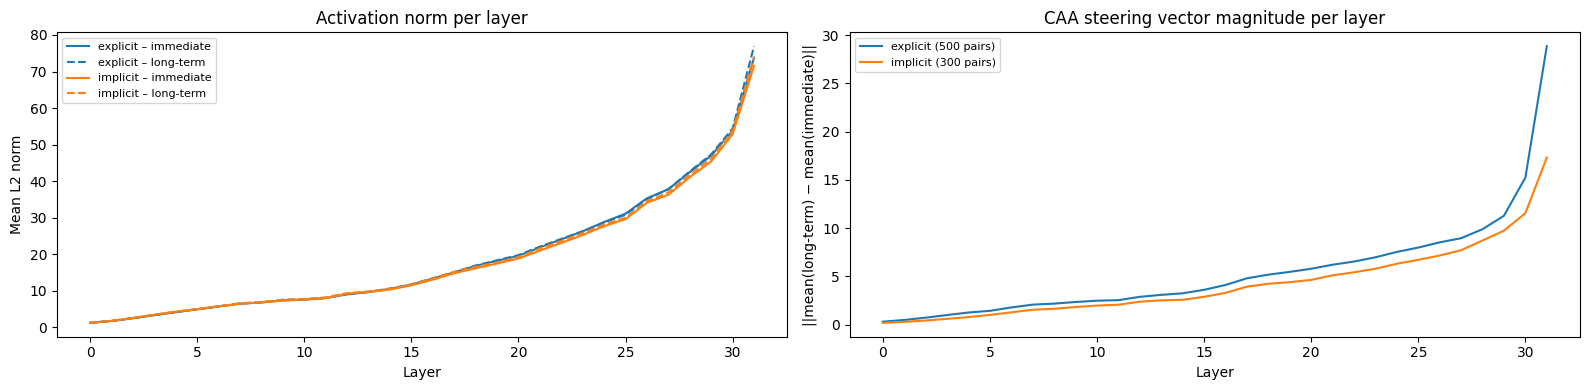

Explicit peak CAA layer: 31  (of 32)
Implicit peak CAA layer: 31  (of 32)


In [57]:
fig, axes = plt.subplots(1, 2, figsize=(16, 4))

# --- Plot 1: Activation norm per layer ---
ax = axes[0]
norms_imm_expl = acts_immediate.norm(dim=-1).mean(dim=0).cpu()
norms_lt_expl  = acts_long_term.norm(dim=-1).mean(dim=0).cpu()
norms_imm_impl = acts_immediate_impl.norm(dim=-1).mean(dim=0).cpu()
norms_lt_impl  = acts_long_term_impl.norm(dim=-1).mean(dim=0).cpu()

ax.plot(norms_imm_expl, label="explicit – immediate",  color="tab:blue",   linestyle="-")
ax.plot(norms_lt_expl,  label="explicit – long-term",  color="tab:blue",   linestyle="--")
ax.plot(norms_imm_impl, label="implicit – immediate",  color="tab:orange",  linestyle="-")
ax.plot(norms_lt_impl,  label="implicit – long-term",  color="tab:orange",  linestyle="--")
ax.set_xlabel("Layer")
ax.set_ylabel("Mean L2 norm")
ax.set_title("Activation norm per layer")
ax.legend(fontsize=8)

# --- Plot 2: CAA vector magnitude per layer ---
ax = axes[1]
diff_expl = (acts_long_term - acts_immediate).mean(dim=0)          # [n_layers, d_model]
diff_impl = (acts_long_term_impl - acts_immediate_impl).mean(dim=0)
diff_norms_expl = diff_expl.norm(dim=-1).cpu()
diff_norms_impl = diff_impl.norm(dim=-1).cpu()

ax.plot(diff_norms_expl, label="explicit (500 pairs)", color="tab:blue")
ax.plot(diff_norms_impl, label="implicit (300 pairs)", color="tab:orange")
ax.set_xlabel("Layer")
ax.set_ylabel("||mean(long-term) − mean(immediate)||")
ax.set_title("CAA steering vector magnitude per layer")
ax.legend(fontsize=8)

plt.tight_layout()
plt.show()

peak_expl = diff_norms_expl.argmax().item()
peak_impl = diff_norms_impl.argmax().item()
print(f"Explicit peak CAA layer: {peak_expl}  (of {runner.n_layers})")
print(f"Implicit peak CAA layer: {peak_impl}  (of {runner.n_layers})")

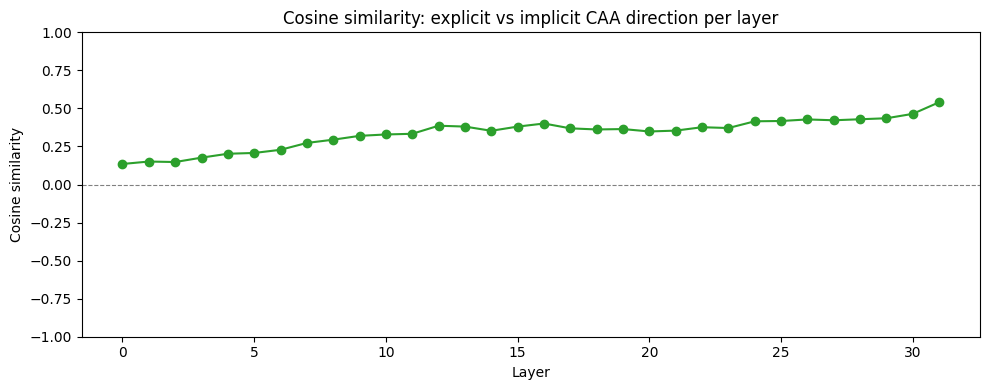

Mean cosine similarity (all layers): 0.337
Max  cosine similarity: 0.541  at layer 31
Min  cosine similarity: 0.135  at layer 0

Interpretation:
  ~1.0  → same temporal direction (semantic, keyword-independent)
  ~0.0  → unrelated directions (explicit driven by surface tokens)
  ~-1.0 → opposite directions (pathological / very different datasets)


In [58]:
# Cosine similarity between the two CAA directions at each layer
# High similarity → the model encodes the same temporal direction regardless of keywords
# Low similarity → explicit keywords drive a different (possibly surface-level) direction

cosine_sims = torch.nn.functional.cosine_similarity(
    diff_expl.float(), diff_impl.float(), dim=-1
).cpu()  # [n_layers]

plt.figure(figsize=(10, 4))
plt.plot(cosine_sims, marker="o", color="tab:green")
plt.axhline(0, color="gray", linestyle="--", linewidth=0.8)
plt.xlabel("Layer")
plt.ylabel("Cosine similarity")
plt.title("Cosine similarity: explicit vs implicit CAA direction per layer")
plt.ylim(-1, 1)
plt.tight_layout()
plt.show()

print(f"Mean cosine similarity (all layers): {cosine_sims.mean():.3f}")
print(f"Max  cosine similarity: {cosine_sims.max():.3f}  at layer {cosine_sims.argmax().item()}")
print(f"Min  cosine similarity: {cosine_sims.min():.3f}  at layer {cosine_sims.argmin().item()}")
print()
print("Interpretation:")
print("  ~1.0  → same temporal direction (semantic, keyword-independent)")
print("  ~0.0  → unrelated directions (explicit driven by surface tokens)")
print("  ~-1.0 → opposite directions (pathological / very different datasets)")

## Focused Steering Experiment

Single prompt: `"The best way to live life is:"` — no temporal keywords, horizon comes from steering.

**Setup:**
- Use explicit dataset (500 pairs) CAA vectors only
- Normalize steering vectors to unit norm (removes scale differences across layers)
- Find top 5 layers by raw CAA magnitude
- Test each layer individually at multiple strengths, then all 5 together
- `+strength` → long-term, `−strength` → short-term / immediate

In [ ]:
# ── Step 1: find top-5 layers by CAA magnitude (explicit dataset only) ──────
# diff_expl was computed earlier: mean(long_term) - mean(immediate) per layer [32, 4096]
caa_norms = diff_expl.norm(dim=-1).cpu()   # [32]

top5_layers = caa_norms.topk(5).indices.tolist()
top5_layers.sort()  # ascending layer order

print("CAA vector norms per layer:")
for i, n in enumerate(caa_norms):
    marker = " ◄ TOP-5" if i in top5_layers else ""
    print(f"  Layer {i:2d}: {n:.2f}{marker}")

print(f"\nTop-5 layers (sorted): {top5_layers}")

In [ ]:
# ── Step 2: normalise steering vectors to unit norm ─────────────────────────
# Raw vectors have very different scales (layer 31 norm ~29 vs layer 15 norm ~3.6).
# Normalising lets `strength` mean the same thing across all layers.
unit_steering = diff_expl.float().cpu().clone()  # [32, 4096]
norms = unit_steering.norm(dim=-1, keepdim=True).clamp(min=1e-8)
unit_steering = unit_steering / norms  # each row is now a unit vector

print("After normalisation:")
for L in top5_layers:
    print(f"  Layer {L:2d}: ||v|| = {unit_steering[L].norm():.6f}  (raw was {caa_norms[L]:.2f})")

In [ ]:
# ── Step 3: steering helpers ─────────────────────────────────────────────────
from src.inference.interventions import Intervention, create_intervention_hook

FOCUS_PROMPT = "The best way to live life is:"
STRENGTHS    = [5, 15, 30, 50]    # applied to unit-norm vectors
MAX_TOKENS   = 120

# Pre-format prompt once (applies chat template if needed, none for base model)
_formatted_prompt = runner.apply_chat_template(FOCUS_PROMPT)


def _encode(text: str) -> torch.Tensor:
    return runner._backend.encode(text)


def _decode(ids: torch.Tensor) -> str:
    return runner._backend.decode(ids)


def _tl_generate(hook_pairs: list, input_ids: torch.Tensor) -> str:
    """Run TransformerLens .generate() with an arbitrary list of (hook_name, fn) pairs."""
    prompt_len = input_ids.shape[1]
    gen_kwargs = dict(
        max_new_tokens=MAX_TOKENS, do_sample=False,
        stop_at_eos=True, verbose=False,
        use_past_kv_cache=False,  # must be False when hooks are active
    )
    with torch.no_grad():
        if hook_pairs:
            with runner._model.hooks(fwd_hooks=hook_pairs):
                output_ids = runner._model.generate(input_ids, **gen_kwargs)
        else:
            output_ids = runner._model.generate(input_ids, **gen_kwargs)
    return _decode(output_ids[0, prompt_len:])


def run_single_layer(layer: int, strength: float, direction: float = 1.0) -> str:
    """Steer at one layer. direction=+1 → long-term, -1 → short-term."""
    iv = Intervention(layer=layer, mode="add",
                      values=(unit_steering[layer] * direction).numpy(),
                      strength=strength)
    hook_fn, _ = create_intervention_hook(iv, dtype=runner.dtype, device=runner.device)
    input_ids = _encode(_formatted_prompt)
    return _tl_generate([(iv.hook_name, hook_fn)], input_ids)


def run_multi_layer(layers: list, strength: float, direction: float = 1.0) -> str:
    """Steer simultaneously at all listed layers with the same strength."""
    hook_pairs = []
    for L in layers:
        iv = Intervention(layer=L, mode="add",
                          values=(unit_steering[L] * direction).numpy(),
                          strength=strength)
        hook_fn, _ = create_intervention_hook(iv, dtype=runner.dtype, device=runner.device)
        hook_pairs.append((iv.hook_name, hook_fn))
    input_ids = _encode(_formatted_prompt)
    return _tl_generate(hook_pairs, input_ids)


# ── Baseline (no steering) ────────────────────────────────────────────────────
input_ids_base = _encode(_formatted_prompt)
baseline_output = _tl_generate([], input_ids_base)
print(f"PROMPT: {FOCUS_PROMPT}")
print(f"\nBASELINE:\n{baseline_output}")

In [ ]:
# ── Step 4: individual-layer sweep ──────────────────────────────────────────
# For each of the top-5 layers × 4 strengths → long-term and short-term output.
# Organise results as a dict: results[layer][strength] = {"long_term": ..., "short_term": ...}

results_single = {}
total = len(top5_layers) * len(STRENGTHS) * 2
done = 0

for L in top5_layers:
    results_single[L] = {}
    for s in STRENGTHS:
        lt_out = run_single_layer(L, s, direction=+1.0)
        st_out = run_single_layer(L, s, direction=-1.0)
        results_single[L][s] = {"long_term": lt_out, "short_term": st_out}
        done += 2
        print(f"  [{done}/{total}] layer={L} strength={s} done")

print("\nAll single-layer runs complete.")

In [ ]:
# ── Step 5: display individual-layer results ────────────────────────────────
SEP  = "─" * 80
SEP2 = "═" * 80

print(f"PROMPT: {FOCUS_PROMPT}")
print(f"BASELINE: {baseline_output}\n")

for L in top5_layers:
    raw_norm = caa_norms[L].item()
    print(SEP2)
    print(f"LAYER {L}  (raw CAA norm = {raw_norm:.2f})")
    print(SEP2)
    for s in STRENGTHS:
        res = results_single[L][s]
        print(f"\n  [strength = {s:3d}]")
        print(f"  LONG-TERM  (+{s}): {res['long_term'].strip()}")
        print(f"  SHORT-TERM (-{s}): {res['short_term'].strip()}")
    print()

In [ ]:
# ── Step 6: combined 5-layer steering sweep ──────────────────────────────────
# Apply unit-norm vectors at all 5 top layers simultaneously.
# Each layer contributes `strength` in the temporal direction.

results_multi = {}
for s in STRENGTHS:
    lt_out = run_multi_layer(top5_layers, s, direction=+1.0)
    st_out = run_multi_layer(top5_layers, s, direction=-1.0)
    results_multi[s] = {"long_term": lt_out, "short_term": st_out}
    print(f"  strength={s} done")

print("\nAll multi-layer runs complete.")

In [ ]:
# ── Step 7: display combined results ────────────────────────────────────────
print(f"PROMPT: {FOCUS_PROMPT}")
print(f"BASELINE: {baseline_output}\n")
print(f"All 5 top layers steered together: {top5_layers}")
print(SEP2)

for s in STRENGTHS:
    res = results_multi[s]
    print(f"\n[strength = {s:3d}]")
    print(f"  LONG-TERM  (+{s}): {res['long_term'].strip()}")
    print(f"  SHORT-TERM (-{s}): {res['short_term'].strip()}")